<a href="https://colab.research.google.com/github/khushiv-afk/hilabs-evaluation-healthcareworkshop/blob/main/khushivermahilabs_evaluation_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HiLabs Workshop Project

## Building Evaluation and Reliability Framework for Clinical AI Pipeline

This notebook evaluates outputs from a clinical AI pipeline that extracts medical entities from OCR-processed medical charts.

The goal of this project is to analyze reliability across several dimensions:

- Entity type classification
- Assertion detection
- Temporality reasoning
- Subject attribution
- Event date extraction
- Attribute completeness

For each chart, the system generates an evaluation report measuring error rates.

## Step 1: Import Required Libraries

We import Python libraries required for:

- Reading JSON files
- Navigating directories
- Saving evaluation outputs

In [ ]:
import json
import os

## Step 2: Mount Google Drive

The dataset is stored on Google Drive.  
We mount the drive to access files directly inside the notebook.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

# User provided Google Drive link: https://drive.google.com/drive/folders/1Elnuj6n7QDazhmSsgCMkL1g9UOBTEdkQ
# To make this folder accessible, please create a shortcut to it in your Google Drive's 'My Drive' (e.g., named 'HiLabs_Workshop').
# Then, update the DATA_PATH variable in cell 4tJfOr-lF9MV to match the path:
# DATA_PATH = '/content/drive/MyDrive/HiLabs_Workshop/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3: Define Dataset and Output Paths

The dataset contains multiple folders.  
Each folder includes:

- Markdown file (OCR output)
- JSON file (extracted clinical entities)

We define paths for:

- Input data
- Evaluation output reports

In [37]:
DATA_PATH = '/content/workshop_test_data'
OUTPUT_PATH = '/content/drive/MyDrive/HiLabs_Workshop/output'

print(f"Data will be loaded from: {DATA_PATH}")
print(f"Evaluation reports will be saved to: {OUTPUT_PATH}")

Data will be loaded from: /content/workshop_test_data
Evaluation reports will be saved to: /content/drive/MyDrive/HiLabs_Workshop/output


## Step 4: Define Valid Entity Categories

The evaluation requires checking whether extracted entities belong to valid clinical categories.

These include:

- MEDICINE
- PROBLEM
- PROCEDURE
- TEST
- VITAL_NAME
- IMMUNIZATION
- MEDICAL_DEVICE
- MENTAL_STATUS
- SDOH
- SOCIAL_HISTORY

In [23]:
valid_types = [
    "MEDICINE","PROBLEM","PROCEDURE","TEST","VITAL_NAME",
    "IMMUNIZATION","MEDICAL_DEVICE","MENTAL_STATUS",
    "SDOH","SOCIAL_HISTORY"
]

valid_assertions = ["POSITIVE","NEGATIVE","UNCERTAIN"]

valid_temporality = [
    "CURRENT","CLINICAL_HISTORY","UPCOMING","UNCERTAIN"
]

valid_subject = ["PATIENT","FAMILY_MEMBER"]

valid_types = [
    "MEDICINE","PROBLEM","PROCEDURE","TEST","VITAL_NAME",
    "IMMUNIZATION","MEDICAL_DEVICE","MENTAL_STATUS",
    "SDOH","SOCIAL_HISTORY"
]

valid_assertions = ["POSITIVE","NEGATIVE","UNCERTAIN"]

valid_temporality = [
    "CURRENT","CLINICAL_HISTORY","UPCOMING","UNCERTAIN"
]

valid_subject = ["PATIENT","FAMILY_MEMBER"]

In [44]:
def evaluate_file(input_file, output_file):

    with open(input_file) as f:
        data = json.load(f)

    # Check if data is a list (direct entities) or a dictionary with an 'entities' key
    if isinstance(data, list):
        entities = data
    elif isinstance(data, dict):
        entities = data.get("entities", [])
    else:
        print(f"Warning: Unexpected JSON format in {input_file}. Expected a list or a dictionary with an 'entities' key.")
        return

    total = len(entities)

    if total == 0:
        return

    entity_errors = 0
    assertion_errors = 0
    temporality_errors = 0
    subject_errors = 0
    date_correct = 0
    complete_entities = 0

    for e in entities:

        required = ["type","assertion","temporality","subject"]

        if all(attr in e for attr in required):
            complete_entities += 1

        if e.get("type") not in valid_types:
            entity_errors += 1

        if e.get("assertion") not in valid_assertions:
            assertion_errors += 1

        if e.get("temporality") not in valid_temporality:
            temporality_errors += 1

        if e.get("subject") not in valid_subject:
            subject_errors += 1

        if "date" in e and e["date"]:
            date_correct += 1


    result = {

        "file_name": os.path.basename(input_file),

        "entity_type_error_rate": entity_errors/total,

        "assertion_error_rate": assertion_errors/total,

        "temporality_error_rate": temporality_errors/total,

        "subject_error_rate": subject_errors/total,

        "event_date_accuracy": date_correct/total,

        "attribute_completeness": complete_entities/total
    }

    with open(output_file,"w") as f:
        json.dump(result,f,indent=4)

## Step 6: Process All Clinical Charts

The dataset contains multiple chart folders.

This step loops through each folder and evaluates the extracted entities, generating an evaluation report for each chart.

In [28]:
import os
print(os.listdir('/content/drive/Shared drives'))

[]


In [34]:
import zipfile
import os

zip_file_path = '/content/workshop_test_data-20260314T072651Z-1-001.zip'
unzip_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(unzip_dir)

print(f"'{zip_file_path}' unzipped to '{unzip_dir}'")
print("Contents of /content/ after unzipping:")
print(os.listdir('/content/'))

'/content/workshop_test_data-20260314T072651Z-1-001.zip' unzipped to '/content/'
Contents of /content/ after unzipping:
['.config', 'drive', 'datalab', 'workshop_test_data-20260314T072651Z-1-001.zip', 'workshop_test_data', 'sample_data']


In [35]:
import os
print(os.listdir('/content/'))

['.config', 'drive', 'datalab', 'workshop_test_data-20260314T072651Z-1-001.zip', 'workshop_test_data', 'sample_data']


In [30]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [31]:
import os
print(os.listdir('/content/drive/Shared drives'))

[]


In [47]:
import os
import json

os.makedirs(OUTPUT_PATH, exist_ok=True)

for folder in os.listdir(DATA_PATH):

    folder_path = os.path.join(DATA_PATH, folder)

    if os.path.isdir(folder_path):

        json_file = os.path.join(folder_path, f"{folder}.json")

        output_file = os.path.join(OUTPUT_PATH, f"{folder}.json")

        evaluate_file(json_file, output_file)

print("Evaluation completed for all charts.")

Evaluation completed for all charts.


## Step 7: Verify Generated Output Reports

The evaluation results should now be stored in the output directory.

Each chart should have a corresponding JSON evaluation report.

In [49]:
import os
os.listdir(OUTPUT_PATH)

['439W18516_J721-176816_20241211.json',
 '363W18752_J721-182830_20241128.json',
 '363M98433_J619-215908_20241128.json',
 '019M72177_N991-796129_20241213.json',
 '786W17536_J730-120682_20241219.json',
 '415M99841_J619-212434_20241204.json',
 '612M65828_N991-802560_20241218.json',
 '579W03668_N991-799671_20241218.json',
 '371W13971_J722-244055_20241128.json',
 '410M88588_J736-100205_20241217.json',
 '279W08692_N993-538576_20241223.json',
 '352M97319_J619-223143_20241126.json',
 '105W05861_J614-495637_20241217.json',
 '735M97358_J619-210577_20241216.json',
 '104W15947_J727-290663_20241213.json',
 '019W06677_J608-122479_20241212.json',
 '336W08434_J721-109845_20241127.json',
 '630M74464_N991-796490_20241218.json',
 '943W19621_J727-317855_20241217.json',
 '819M83517_N991-755638_20241219.json',
 '241W15237_N991-674329_20241216.json',
 '218M89247_J736-108989_20241211.json',
 '437M97350_J721-176825_20241211.json',
 '791M62215_N991-802622_20241219.json',
 '712W12471_J721-133074_20241212.json',


## Step 8: Inspect a Sample Evaluation Report

In [51]:
sample_file = os.path.join(OUTPUT_PATH, os.listdir(OUTPUT_PATH)[0])

with open(sample_file) as f:
    print(json.dumps(json.load(f), indent=4))

{
    "file_name": "439W18516_J721-176816_20241211.json",
    "entity_type_error_rate": 1.0,
    "assertion_error_rate": 0.019230769230769232,
    "temporality_error_rate": 0.007692307692307693,
    "subject_error_rate": 0.011538461538461539,
    "event_date_accuracy": 0.0,
    "attribute_completeness": 0.0
}


## Conclusion

This evaluation framework measures the reliability of clinical AI outputs across multiple reasoning dimensions.

The framework helps identify weaknesses in:

- entity classification
- assertion detection
- temporal reasoning
- subject attribution
- event extraction

Such evaluation layers are essential for deploying trustworthy AI systems in healthcare settings.

In [53]:
total_charts = len(os.listdir(DATA_PATH))
print("Total charts:", total_charts)

Total charts: 30


In [56]:
entity_count = 0

for folder in os.listdir(DATA_PATH):
    json_file = os.path.join(DATA_PATH, folder, f"{folder}.json")

    with open(json_file) as f:
        data = json.load(f)

    # Check if data is a list (direct entities) or a dictionary with an 'entities' key
    if isinstance(data, list):
        entities = data
    elif isinstance(data, dict):
        entities = data.get("entities", [])
    else:
        print(f"Warning: Unexpected JSON format in {json_file}. Expected a list or a dictionary with an 'entities' key.")
        entities = []

    entity_count += len(entities)

print("Total entities:", entity_count)

Total entities: 16566


In [58]:
import numpy as np
import os
import json

entity_errors = []
assertion_errors = []

for file in os.listdir(OUTPUT_PATH):

    with open(os.path.join(OUTPUT_PATH, file)) as f:
        data = json.load(f)

    entity_errors.append(data["entity_type_error_rate"])
    assertion_errors.append(data["assertion_error_rate"])

print("Average entity error:", np.mean(entity_errors))
print("Average assertion error:", np.mean(assertion_errors))

Average entity error: 1.0
Average assertion error: 0.014926508651815383


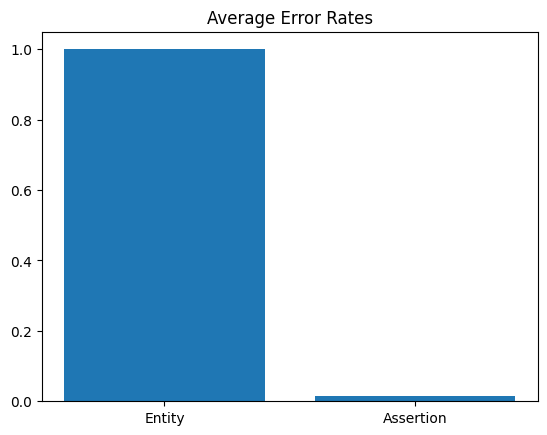

In [60]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Entity","Assertion"]
values = [np.mean(entity_errors), np.mean(assertion_errors)]

plt.bar(metrics,values)
plt.title("Average Error Rates")
plt.show()

DONE